In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scienceplots

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 320
V_INPUT     = np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS, endpoint=False)
V_I_PLOT    = 1000*V_INPUT
PATH        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/temperature/"
V_CTRL_VALS = [0.005,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05]
V_CTRL_POS  = [1,3,5]

### IV-Curves at Cg=0.28

In [3]:
data = {pos : {i : pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=8_{pos}_{i}.csv").sort_values(by='E0',ignore_index=True) for i in range(len(V_CTRL_VALS))} for pos in V_CTRL_POS}

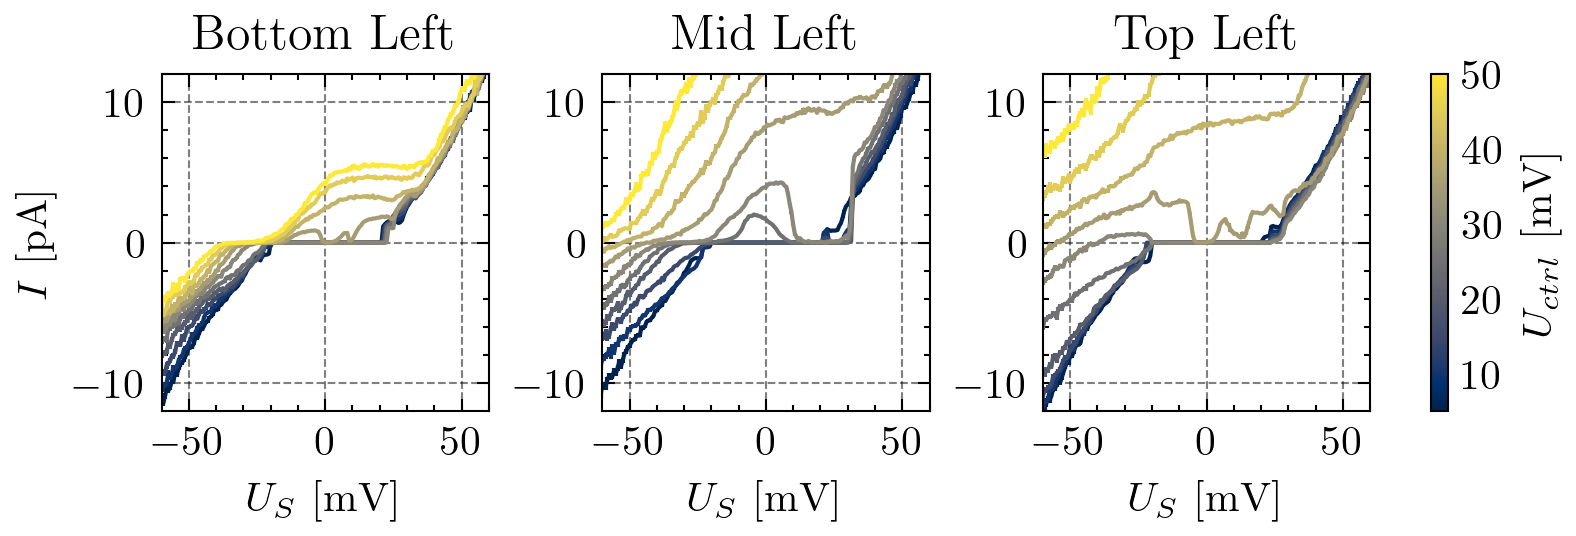

In [35]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=1000*V_CTRL_VALS[0],vmax=1000*V_CTRL_VALS[-1])
fig     = plt.figure(dpi=300, layout='constrained')
_       = fig.set_figwidth(fig.get_figwidth()*2.0)
_       = fig.set_figheight(fig.get_figheight()*0.9)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
axs     = []
titles  = ['Bottom Left', 'Mid Left', 'Top Left']
for j, pos in enumerate(V_CTRL_POS):
    ax = fig.add_subplot(1,3,j+1)
    axs.append(ax)
    for i, V in enumerate(V_CTRL_VALS):
        df  = data[pos][i].copy()
        x   = df['E0'].values*1000
        y   = df['Observable'].values*1e-6
        y_e = df['Error'].values*1e-6
        _   = ax.errorbar(x, y, y_e, color=cmap(norm(1000*V)))

    if j == 0:
        _   = ax.set_ylabel("$I~[\mathrm{pA}]$")
    _   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
    _   = ax.set_xlim(-60,60)
    _   = ax.set_ylim(-12,12)
    _   = ax.set_title(titles[j])

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=axs)
_       = cbar.set_label("$U_{ctrl}~[\mathrm{mV}]$")
_       = cbar.set_ticks([10,20,30,40,50])

fig.savefig(f"plots/svg/network_iv_curves_ctrl.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_ctrl.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_ctrl.png", transparent=False)